This notebook implements the Reptile meta-learning algorithm for few-shot image classification on the Omniglot dataset. The goal is to train a convolutional neural network such that it can quickly adapt to new classification tasks (5-way, 1-shot) using only a few examples. The workflow includes building a task sampler, performing inner-loop adaptation on support sets, and updating a meta-model across many sampled tasks.

We experiment with different training configurations such as inner-loop steps, meta learning rate, and normalization strategies to understand their impact on generalization. The notebook also includes validation-based model selection and evaluation on unseen test tasks to assess how well the learned initialization transfers to new classes.

# Importing Essential Libraries

In [1]:
import os
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

import torch
import torch.nn as nn
import torch.optim as optim


# Dataset Preprocessing

## Reproducibility, Device Selection, and Image Preprocessing

In this step, we set a fixed random seed to make the experiment more reproducible. Reptile training depends on many random operations, such as sampling tasks, selecting Omniglot classes, choosing support/query images, and initializing model parameters. Fixing the seed helps make the training behavior more consistent across runs.

We also select the computation device. If a GPU is available, the model and tensors are moved to CUDA; otherwise, the notebook runs on CPU. Since Reptile performs many repeated inner-loop adaptations, using a GPU is important for faster training.

Finally, we define the preprocessing transform for Omniglot images. Each image is resized to `28 × 28` and converted into a PyTorch tensor. Omniglot images are grayscale, so after preprocessing each image has shape `[1, 28, 28]`.

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [3]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

In [4]:
train_root = "/kaggle/input/datasets/watesoyan/omniglot/images_background"
test_root  = "/kaggle/input/datasets/watesoyan/omniglot/images_evaluation"

In [5]:
import os

def count_images(root_dir):
    count = 0
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)

        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)

            if not os.path.isdir(character_path):
                continue

            count += len(os.listdir(character_path))

    return count


print("Train Samples:", count_images(train_root))
print("Test Samples:", count_images(test_root))

Train Samples: 19280
Test Samples: 13180


📂 Building Class-wise Dataset and Meta-Splits

In this step, the Omniglot dataset is reorganized into a format suitable for meta-learning by grouping images according to their character classes. The build_class_dict function iterates through the dataset directory, loads each image in grayscale, applies the preprocessing transformations, and stores them in a dictionary where each key represents a unique class (alphabet/character) and maps to all corresponding image tensors. This structure allows us to easily sample tasks later during meta-training.

After constructing the full dataset, the training classes are randomly shuffled and split into meta-train (80%) and meta-validation (20%) sets, while the test classes are kept completely separate. This ensures that the model is trained and validated on different sets of classes, and finally evaluated on entirely unseen classes, which is crucial for assessing few-shot generalization.

In [6]:
import os
import random
from PIL import Image


def build_class_dict(root_dir, transform, split_name=""):
    
    class_dict = {}

    for alphabet in sorted(os.listdir(root_dir)):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue

        for character in sorted(os.listdir(alphabet_path)):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue

            images = []
            for img_name in sorted(os.listdir(character_path)):
                img_path = os.path.join(character_path, img_name)
                if not os.path.isfile(img_path) or not img_name.endswith(".png"):
                    continue

                image = Image.open(img_path).convert("L")
                image_tensor = transform(image)  # [1, 28, 28]
                images.append(image_tensor)

            class_id = f"{split_name}/{alphabet}/{character}" if split_name else f"{alphabet}/{character}"
            class_dict[class_id] = images

    return class_dict


background_classes = build_class_dict(train_root, transform, split_name="background")
evaluation_classes = build_class_dict(test_root, transform, split_name="evaluation")

all_classes = {}
all_classes.update(background_classes)
all_classes.update(evaluation_classes)

print("Background classes:", len(background_classes))
print("Evaluation classes:", len(evaluation_classes))
print("Merged Omniglot classes:", len(all_classes))

example_key = next(iter(all_classes))
print("Example class key:", example_key)
print("Images per example class:", len(all_classes[example_key]))


Background classes: 964
Evaluation classes: 659
Merged Omniglot classes: 1623
Example class key: background/Alphabet_of_the_Magi/character01
Images per example class: 20



## Few-Shot Task Sampler

In this step, we define the task sampler used to create Omniglot few-shot learning episodes. Reptile does not train on ordinary fixed mini-batches like standard supervised learning. Instead, it repeatedly samples small tasks. Each task contains a small number of classes and a small number of examples per class.

The `OmniglotTaskSampler` takes the class-wise dictionary created earlier and samples tasks from it. Each selected Omniglot character becomes one class inside the current task. The labels are assigned locally, meaning that the selected classes are labelled as `0, 1, 2, ...` only for that specific task. These labels do not represent permanent dataset labels.

The function `sample_support_set()` is used during meta-training. It samples only the support set, which is used for inner-loop adaptation. The function `sample_task()` is used during validation and testing. It samples both a support set and a query set. The support set is used to adapt the copied model, while the query set is used to measure how well the adapted model generalizes.

For the final 5-way 1-shot setting, evaluation uses 5 classes with 1 support image per class. This means the model must adapt to a new task using only 5 labelled examples in total.


In [7]:
import random
import torch


class OmniglotTaskSampler:
    def __init__(self, class_to_images):
        """
        class_to_images:
            dict where key = class_id and value = list of image tensors.
        """
        self.class_to_images = class_to_images
        self.class_ids = list(class_to_images.keys())

    def sample_support_set(self, n_way=5, shots=10):
        
        selected_classes = random.sample(self.class_ids, n_way)
        support_images = []
        support_labels = []

        for local_label, class_id in enumerate(selected_classes):
            images = self.class_to_images[class_id]
            if len(images) < shots:
                raise ValueError(
                    f"Class {class_id} has only {len(images)} images, but {shots} are required."
                )

            sampled_images = random.sample(images, shots)
            support_images.extend(sampled_images)
            support_labels.extend([local_label] * shots)

        support_x = torch.stack(support_images)
        support_y = torch.tensor(support_labels, dtype=torch.long)
        return support_x, support_y

    def sample_task(self, n_way=5, k_shot=1, q_query=1):
        """
        Sample one N-way K-shot evaluation task.
            support set = 5 classes x 1 image  = 5 images
            query set   = 5 classes x 1 image  = 5 images
        """
        selected_classes = random.sample(self.class_ids, n_way)

        support_images = []
        support_labels = []
        query_images = []
        query_labels = []

        for local_label, class_id in enumerate(selected_classes):
            images = self.class_to_images[class_id]
            total_needed = k_shot + q_query

            if len(images) < total_needed:
                raise ValueError(
                    f"Class {class_id} has only {len(images)} images, "
                    f"but {total_needed} are required."
                )

            sampled_images = random.sample(images, total_needed)
            support_imgs = sampled_images[:k_shot]
            query_imgs = sampled_images[k_shot:]

            support_images.extend(support_imgs)
            query_images.extend(query_imgs)
            support_labels.extend([local_label] * k_shot)
            query_labels.extend([local_label] * q_query)

        support_x = torch.stack(support_images)
        support_y = torch.tensor(support_labels, dtype=torch.long)
        query_x = torch.stack(query_images)
        query_y = torch.tensor(query_labels, dtype=torch.long)

        return support_x, support_y, query_x, query_y


In [9]:
all_class_ids = list(all_classes.keys())
random.shuffle(all_class_ids)

split_idx = int(0.9 * len(all_class_ids))

meta_train_ids = all_class_ids[:split_idx]
meta_val_ids = all_class_ids[split_idx:]

meta_train_classes = {cid: all_classes[cid] for cid in meta_train_ids}
meta_val_classes = {cid: all_classes[cid] for cid in meta_val_ids}

train_sampler = OmniglotTaskSampler(meta_train_classes)
val_sampler = OmniglotTaskSampler(meta_val_classes)

test_sampler = val_sampler

print("Meta-train classes:", len(meta_train_classes))
print("Meta-val classes:", len(meta_val_classes))
print("Meta-test/validation classes:", len(meta_val_classes))


Meta-train classes: 1460
Meta-val classes: 163
Meta-test/validation classes: 163


In [10]:
import matplotlib.pyplot as plt

def visualize_task(support_x, support_y, query_x, query_y, n_way=5, k_shot=1, q_query=5):
    

    total_cols = max(n_way * k_shot, n_way * q_query)

    plt.figure(figsize=(15, 4))

    #Support set
    for i in range(n_way * k_shot):
        plt.subplot(2, total_cols, i + 1)
        plt.imshow(support_x[i].squeeze(0), cmap="gray")
        plt.title(f"S:{support_y[i].item()}")
        plt.axis("off")

    #Query set
    for i in range(n_way * q_query):
        plt.subplot(2, total_cols, total_cols + i + 1)
        plt.imshow(query_x[i].squeeze(0), cmap="gray")
        plt.title(f"Q:{query_y[i].item()}")
        plt.axis("off")

    plt.suptitle("Support (Top) vs Query (Bottom)")
    plt.tight_layout()
    plt.show()

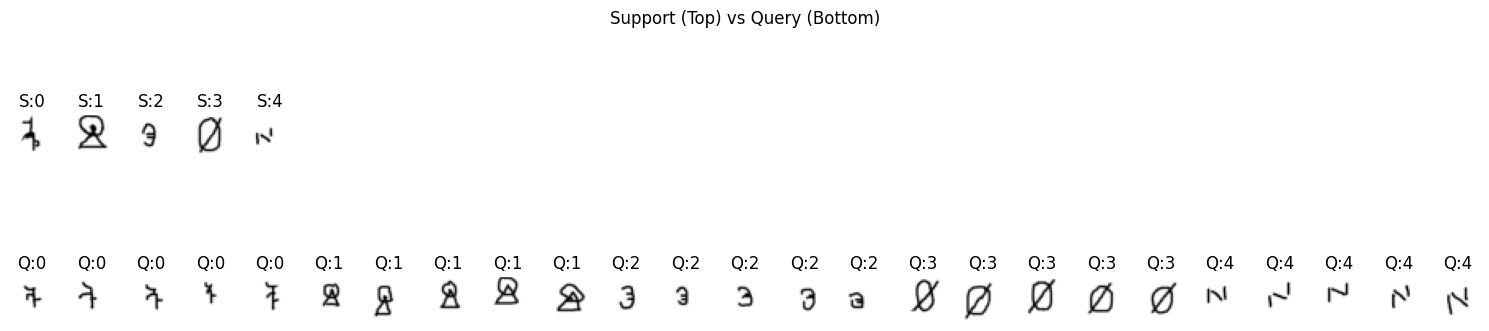

In [11]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=5,
    k_shot=1,
    q_query=5
)

visualize_task(support_x, support_y, query_x, query_y)

In [12]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=5,
    k_shot=1,
    q_query=5
)

print("Support labels:", support_y)
print("Query labels:", query_y)
print("Unique support labels:", torch.unique(support_y))
print("Unique query labels:", torch.unique(query_y))

Support labels: tensor([0, 1, 2, 3, 4])
Query labels: tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
        4])
Unique support labels: tensor([0, 1, 2, 3, 4])
Unique query labels: tensor([0, 1, 2, 3, 4])


In [13]:
print("Support label set:", set(support_y.tolist()))
print("Query label set:", set(query_y.tolist()))

Support label set: {0, 1, 2, 3, 4}
Query label set: {0, 1, 2, 3, 4}


# Model 

## Reptile Model and Omniglot CNN Architecture

In this step, we define the model used for Omniglot 5-way 1-shot classification.

The first class, `ReptileModel`, adds helper methods needed for the Reptile outer update. The method `point_grad_to()` computes the difference between the current meta-model and the task-adapted model. This difference is stored as a pseudo-gradient so that an SGD optimizer can move the meta-model toward the adapted model.

The second class, `OmniglotCNN`, defines the convolutional neural network used for few-shot classification. The architecture contains four convolutional blocks. Each block uses:

```text
Conv2d → BatchNorm2d → ReLU

In [14]:
class ReptileModel(nn.Module):
    def point_grad_to(self, target):
        
        for p, target_p in zip(self.parameters(), target.parameters()):
            if p.grad is None:
                p.grad = torch.zeros_like(p)
            p.grad.data.zero_()
            p.grad.data.add_(p.data - target_p.data)

    def is_cuda(self):
        return next(self.parameters()).is_cuda


class OmniglotCNN(ReptileModel):
    
    def __init__(self, n_way):
        super().__init__()
        self.n_way = n_way

        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, n_way),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def predict(self, log_probs):
        return log_probs.argmax(dim=1)

    def clone(self):
        cloned = OmniglotCNN(self.n_way)
        cloned.load_state_dict(self.state_dict())
        cloned = cloned.to(next(self.parameters()).device)
        return cloned


## Inner-Loop Adaptation on a Sampled Task

In this step, we define how the model adapts to one sampled Omniglot task. This is the inner loop of Reptile.

The model first starts from the current meta-model initialization. A copy of the meta-model is created, and this copied model is trained only on the support set of the sampled task. This gives a task-adapted model. The original meta-model is not directly updated inside this function.

The loss function used here is `NLLLoss`, because the CNN outputs log-probabilities using `LogSoftmax`. Therefore, the correct pairing is:

```text
LogSoftmax + NLLLoss
````

The task model is adapted using Adam with `β1 = 0` and `β2 = 0.999`. Setting `β1 = 0` removes momentum, which is useful for Reptile because the algorithm depends on the effect of sequential mini-batch updates inside the task.

This function also supports reusing Adam optimizer state during meta-training. If an optimizer state is passed, it is loaded into the Adam optimizer and moved to the correct device. This is important when training on GPU or resuming from checkpoints.

A key detail is that `inner_steps` means the number of mini-batch optimizer updates, not the number of full passes over the support set. This was important for matching the intended Reptile behavior.

In [15]:
criterion = nn.NLLLoss()


def _move_optimizer_state_to_device(optimizer, device):

    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)


def adapt_on_task(
    meta_model,
    support_x,
    support_y,
    inner_lr=0.00044,
    inner_steps=12,
    inner_batch_size=10,
    optimizer_state=None,
    return_optimizer_state=False,
    device=device
):
    
    support_x = support_x.to(device)
    support_y = support_y.to(device)

    task_model = meta_model.clone().to(device)
    task_model.train()

    optimizer = torch.optim.Adam(
        task_model.parameters(),
        lr=inner_lr,
        betas=(0.0, 0.999)
    )

    if optimizer_state is not None:
        optimizer.load_state_dict(optimizer_state)
        _move_optimizer_state_to_device(optimizer, device)

    n = support_x.size(0)
    support_loss_value = None

    perm = torch.randperm(n, device=device)
    cursor = 0

    for _ in range(inner_steps):
        if cursor + inner_batch_size > n:
            perm = torch.randperm(n, device=device)
            cursor = 0

        batch_idx = perm[cursor:cursor + inner_batch_size]
        cursor += inner_batch_size

        batch_x = support_x[batch_idx]
        batch_y = support_y[batch_idx]

        optimizer.zero_grad()
        log_probs = task_model(batch_x)
        loss = criterion(log_probs, batch_y)
        loss.backward()
        optimizer.step()

        support_loss_value = loss.item()

    if return_optimizer_state:
        return task_model, support_loss_value, copy.deepcopy(optimizer.state_dict())

    return task_model, support_loss_value


## Computing the Reptile Task Delta

In this step, we compute the parameter difference between the adapted task model and the original meta-model.

After inner-loop adaptation, the copied model has moved from the meta-initialization toward parameters that perform better on the sampled task. Reptile uses this movement direction to update the meta-model.

Mathematically, for one task, the task delta is:

$$
\Delta_\tau = \tilde{\phi} - \phi
$$

where:

- $\phi$ is the original meta-model parameter vector.
- $\tilde{\phi}$ is the adapted task-model parameter vector after inner-loop training.
- $\Delta_\tau$ is the direction in which the meta-model should move.

This delta tells us how the model changed after learning one task. The Reptile outer update then moves the meta-model slightly in this direction:

$$
\phi \leftarrow \phi + \epsilon \Delta_\tau
$$

Since:

$$
\Delta_\tau = \tilde{\phi} - \phi
$$

the update can also be written as:

$$
\phi \leftarrow \phi + \epsilon(\tilde{\phi} - \phi)
$$

In simple terms, Reptile checks how the model changed after adapting to one task, and then moves the original meta-model a little bit toward that adapted model.

In [16]:
def compute_task_delta(meta_model, task_model):
    return [
        (task_param - meta_param).detach()
        for meta_param, task_param in zip(meta_model.parameters(), task_model.parameters())
    ]

## Evaluating One Few-Shot Task

In this step, we define how to evaluate the meta-model on one sampled few-shot task.

The function receives a support set and a query set. The support set is used for adaptation, while the query set is used only for evaluation. First, the model is adapted on the support examples using the `adapt_on_task()` function. This creates a task-specific model starting from the current meta-model initialization.

For the final 5-way 1-shot setting, the model adapts using:

- `inner_lr = 0.00044`
- `inner_steps = 86`
- `inner_batch_size = 10`

This means that during evaluation, the copied model performs 86 mini-batch optimizer updates on the support set before being tested on the query set.

After adaptation, the task model is switched to evaluation mode using `task_model.eval()`. This is important because the model contains BatchNorm layers. In evaluation mode, the query set is used only to compute predictions and accuracy, not to update BatchNorm statistics.

The query images are then passed through the adapted model. Since the model outputs log-probabilities, `NLLLoss` is used to compute the query loss. The predicted class is selected using the highest log-probability.

The function finally returns:

- `query_loss`: how wrong the adapted model is on the query set.
- `query_acc`: how many query images were classified correctly.

This function measures the main few-shot learning objective: after seeing only a small support set, how well can the model generalize to new query examples from the same task?

In [17]:
criterion = nn.NLLLoss()


def evaluate_task(
    meta_model,
    support_x,
    support_y,
    query_x,
    query_y,
    inner_lr=0.00044,
    inner_steps=86,
    inner_batch_size=10,
    optimizer_state=None,
    transductive=False,
    device=device
):
    support_x = support_x.to(device)
    support_y = support_y.to(device)
    query_x = query_x.to(device)
    query_y = query_y.to(device)

    task_model, _ = adapt_on_task(
        meta_model=meta_model,
        support_x=support_x,
        support_y=support_y,
        inner_lr=inner_lr,
        inner_steps=inner_steps,
        inner_batch_size=inner_batch_size,
        optimizer_state=optimizer_state,
        return_optimizer_state=False,
        device=device
    )

    task_model.eval()

    with torch.no_grad():
        log_probs = task_model(query_x)
        query_loss = criterion(log_probs, query_y).item()
        query_preds = task_model.predict(log_probs)
        query_acc = (query_preds == query_y).float().mean().item()

    return query_loss, query_acc


## Evaluating the Model Across Many Few-Shot Tasks

In this step, we evaluate the meta-model over many randomly sampled few-shot tasks.

Evaluating on only one task is not reliable because each sampled Omniglot task can have different difficulty depending on which character classes are selected. Some characters may be easy to distinguish, while others may look very similar. Therefore, we sample many tasks and average the query loss and query accuracy.

For each task, the function:

1. Samples a new 5-way 1-shot task from the test or validation sampler.
2. Adapts the copied model on the support set.
3. Evaluates the adapted model on the query set.
4. Stores the query loss and query accuracy.

At the end, the function returns the average query loss and average query accuracy across all sampled tasks. This gives a more stable estimate of the model’s few-shot generalization performance.

In [18]:
def evaluate_many_tasks(
    meta_model,
    test_sampler,
    num_tasks=100,
    n_way=5,
    k_shot=1,
    q_query=5,
    inner_lr=0.00044,
    inner_steps=86,
    inner_batch_size=10,
    optimizer_state=None,
    transductive=False,
    device=device
):
    losses = []
    accs = []

    for _ in range(num_tasks):
        support_x, support_y, query_x, query_y = test_sampler.sample_task(
            n_way=n_way,
            k_shot=k_shot,
            q_query=q_query
        )

        query_loss, query_acc = evaluate_task(
            meta_model=meta_model,
            support_x=support_x,
            support_y=support_y,
            query_x=query_x,
            query_y=query_y,
            inner_lr=inner_lr,
            inner_steps=inner_steps,
            inner_batch_size=inner_batch_size,
            optimizer_state=optimizer_state,
            transductive=transductive,
            device=device
        )

        losses.append(query_loss)
        accs.append(query_acc)

    return sum(losses) / len(losses), sum(accs) / len(accs)


## Saving and Loading Training Checkpoints

In this step, we define helper functions for saving and loading checkpoints during training.

This is important because Reptile training can take a long time, especially for the final 5-way 1-shot run with 200,000 meta-iterations. Since Kaggle sessions can stop or restart, checkpointing allows us to continue training from the last saved point instead of starting again from zero.

The checkpoint stores:

- the current model parameters
- the current meta-iteration
- the training history
- the best validation accuracy so far
- the best model state
- the outer meta-optimizer state
- the inner Adam optimizer state

Saving the `best_model_state` is important because the best validation accuracy may happen before the final training iteration. Therefore, after training finishes, we can load the best-performing model instead of only using the last model.

The `inner_optimizer_state` is also saved because the final implementation reuses Adam optimizer state during meta-training. Saving this state makes resumed training more consistent with uninterrupted training.

In [19]:
import os
import copy
import torch


def save_checkpoint(
    checkpoint_path,
    model,
    meta_iter,
    history,
    best_eval_acc,
    best_model_state,
    meta_optimizer_state=None,
    inner_optimizer_state=None
):
    checkpoint = {
        "model_state": model.state_dict(),
        "meta_iter": meta_iter,
        "history": history,
        "best_eval_acc": best_eval_acc,
        "best_model_state": best_model_state,
        "meta_optimizer_state": meta_optimizer_state,
        "inner_optimizer_state": inner_optimizer_state,
    }

    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved at iteration {meta_iter}: {checkpoint_path}")


def load_checkpoint(checkpoint_path, model, device, meta_optimizer=None):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])

    if meta_optimizer is not None and checkpoint.get("meta_optimizer_state") is not None:
        meta_optimizer.load_state_dict(checkpoint["meta_optimizer_state"])

    start_iter = checkpoint["meta_iter"] + 1
    history = checkpoint["history"]
    best_eval_acc = checkpoint["best_eval_acc"]
    best_model_state = checkpoint["best_model_state"]
    inner_optimizer_state = checkpoint.get("inner_optimizer_state", None)

    print(f"Checkpoint loaded. Resuming from iteration {start_iter}")

    return model, start_iter, history, best_eval_acc, best_model_state, inner_optimizer_state


## Main Reptile Meta-Training Loop

In this step, we define the main Reptile training loop for the 5-way 1-shot Omniglot experiment.

This function combines the full meta-learning process:

1. Sample a few-shot task.
2. Adapt a copied model on the task support set.
3. Move the meta-model toward the adapted task model.
4. Periodically evaluate the meta-model on validation tasks.
5. Save checkpoints so training can be resumed later.
6. Track the best validation model.

The final 5-way 1-shot configuration uses serial Reptile, because `tasks_per_meta_batch = 1`. This means that each meta-iteration uses one sampled task. The task model is adapted using Adam in the inner loop, while the meta-model is updated using an SGD-style Reptile outer update.

The meta step size is linearly annealed from `0.33` to `0.0`. This means the meta-model moves more strongly at the beginning of training and more carefully near the end. This helps early learning while improving stability later.

The function also evaluates the model every `eval_every` iterations. During validation, the model is adapted on support examples and tested on query examples across many sampled tasks. The best validation model is saved and loaded at the end.

In [20]:
def reptile_train(
    meta_model,
    train_sampler,
    meta_iters=200000,
    tasks_per_meta_batch=1,
    n_way=5,
    train_shots=12,
    inner_lr=0.00044,
    inner_steps=12,
    inner_batch_size=10,
    meta_step=0.33,
    meta_step_final=0.0,
    eval_sampler=None,
    eval_every=1000,
    eval_tasks=100,
    eval_inner_steps=86,
    eval_inner_batch_size=10,
    transductive=False,
    device=device,
    checkpoint_dir="/kaggle/working/reptile_checkpoints_repo_exact",
    checkpoint_every=10000,
    resume_from=None
):
    
    if tasks_per_meta_batch != 1:
        print("Warning: the reference repo does not implement meta-batch > 1. Using tasks_per_meta_batch=1.")
        tasks_per_meta_batch = 1

    os.makedirs(checkpoint_dir, exist_ok=True)
    meta_model = meta_model.to(device)

    meta_optimizer = torch.optim.SGD(meta_model.parameters(), lr=meta_step)
    inner_optimizer_state = None
    start_iter = 1

    history = {
        "train_support_losses": [],
        "eval_query_losses": [],
        "eval_query_accuracies": [],
        "best_eval_acc": -1.0
    }

    best_eval_acc = -1.0
    best_model_state = copy.deepcopy(meta_model.state_dict())

    if resume_from is not None:
        meta_model, start_iter, history, best_eval_acc, best_model_state, inner_optimizer_state = load_checkpoint(
            checkpoint_path=resume_from,
            model=meta_model,
            device=device,
            meta_optimizer=meta_optimizer
        )

    for meta_iter in range(start_iter, meta_iters + 1):
        meta_model.train()


        frac_done = (meta_iter - 1) / max(1, meta_iters - 1)
        current_meta_step = meta_step + frac_done * (meta_step_final - meta_step)
        for group in meta_optimizer.param_groups:
            group["lr"] = current_meta_step

        support_x, support_y = train_sampler.sample_support_set(
            n_way=n_way,
            shots=train_shots
        )

        task_model, support_loss_value, inner_optimizer_state = adapt_on_task(
            meta_model=meta_model,
            support_x=support_x,
            support_y=support_y,
            inner_lr=inner_lr,
            inner_steps=inner_steps,
            inner_batch_size=inner_batch_size,
            optimizer_state=inner_optimizer_state,
            return_optimizer_state=True,
            device=device
        )

        meta_optimizer.zero_grad()
        meta_model.point_grad_to(task_model)
        meta_optimizer.step()

        history["train_support_losses"].append((meta_iter, support_loss_value))

        if eval_sampler is not None and meta_iter % eval_every == 0:
            eval_query_loss, eval_query_acc = evaluate_many_tasks(
                meta_model=meta_model,
                test_sampler=eval_sampler,
                num_tasks=eval_tasks,
                n_way=n_way,
                k_shot=1,
                q_query=5,
                inner_lr=inner_lr,
                inner_steps=eval_inner_steps,
                inner_batch_size=eval_inner_batch_size,
                optimizer_state=inner_optimizer_state,
                transductive=transductive,
                device=device
            )

            history["eval_query_losses"].append((meta_iter, eval_query_loss))
            history["eval_query_accuracies"].append((meta_iter, eval_query_acc))

            print(
                f"[Meta-iter {meta_iter:6d}/{meta_iters}] "
                f"meta_step={current_meta_step:.4f} | "
                f"train_support_loss={support_loss_value:.4f} | "
                f"eval_query_loss={eval_query_loss:.4f} | "
                f"eval_query_acc={eval_query_acc * 100:.2f}%"
            )

            if eval_query_acc > best_eval_acc:
                best_eval_acc = eval_query_acc
                best_model_state = copy.deepcopy(meta_model.state_dict())
                history["best_eval_acc"] = best_eval_acc

        if meta_iter % checkpoint_every == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"reptile_iter_{meta_iter}.pt")
            save_checkpoint(
                checkpoint_path=checkpoint_path,
                model=meta_model,
                meta_iter=meta_iter,
                history=history,
                best_eval_acc=best_eval_acc,
                best_model_state=best_model_state,
                meta_optimizer_state=meta_optimizer.state_dict(),
                inner_optimizer_state=inner_optimizer_state
            )

    final_checkpoint_path = os.path.join(checkpoint_dir, f"reptile_final_iter_{meta_iters}.pt")
    save_checkpoint(
        checkpoint_path=final_checkpoint_path,
        model=meta_model,
        meta_iter=meta_iters,
        history=history,
        best_eval_acc=best_eval_acc,
        best_model_state=best_model_state,
        meta_optimizer_state=meta_optimizer.state_dict(),
        inner_optimizer_state=inner_optimizer_state
    )

    if eval_sampler is not None and best_eval_acc >= 0:
        meta_model.load_state_dict(best_model_state)
        print(f"Loaded best model with eval accuracy: {best_eval_acc * 100:.2f}%")

    return meta_model, history


In [21]:
n_way = 5
meta_model = OmniglotCNN(n_way=n_way).to(device)

meta_model, history = reptile_train(
    meta_model=meta_model,
    train_sampler=train_sampler,
    eval_sampler=val_sampler,

    meta_iters=200000,
    tasks_per_meta_batch=1,
    n_way=5,
    train_shots=12,

    inner_lr=0.00044,
    inner_steps=12,
    inner_batch_size=10,

    meta_step=0.33,
    meta_step_final=0.0,

    eval_every=1000,
    eval_tasks=100,
    eval_inner_steps=86,
    eval_inner_batch_size=10,

    transductive=False,
    device=device,

    checkpoint_dir="/kaggle/working/reptile_checkpoints_repo_exact",
    checkpoint_every=10000,
    resume_from=None
)


[Meta-iter   1000/200000] meta_step=0.3284 | train_support_loss=0.0512 | eval_query_loss=0.8625 | eval_query_acc=67.96%
[Meta-iter   2000/200000] meta_step=0.3267 | train_support_loss=0.0706 | eval_query_loss=0.6674 | eval_query_acc=75.84%
[Meta-iter   3000/200000] meta_step=0.3251 | train_support_loss=0.0431 | eval_query_loss=0.6048 | eval_query_acc=78.40%
[Meta-iter   4000/200000] meta_step=0.3234 | train_support_loss=0.1992 | eval_query_loss=0.6778 | eval_query_acc=74.88%
[Meta-iter   5000/200000] meta_step=0.3218 | train_support_loss=0.0176 | eval_query_loss=0.6398 | eval_query_acc=76.44%
[Meta-iter   6000/200000] meta_step=0.3201 | train_support_loss=0.0405 | eval_query_loss=0.5675 | eval_query_acc=80.28%
[Meta-iter   7000/200000] meta_step=0.3185 | train_support_loss=0.0633 | eval_query_loss=0.5795 | eval_query_acc=79.44%
[Meta-iter   8000/200000] meta_step=0.3168 | train_support_loss=0.0373 | eval_query_loss=0.5810 | eval_query_acc=80.12%
[Meta-iter   9000/200000] meta_step=0.31

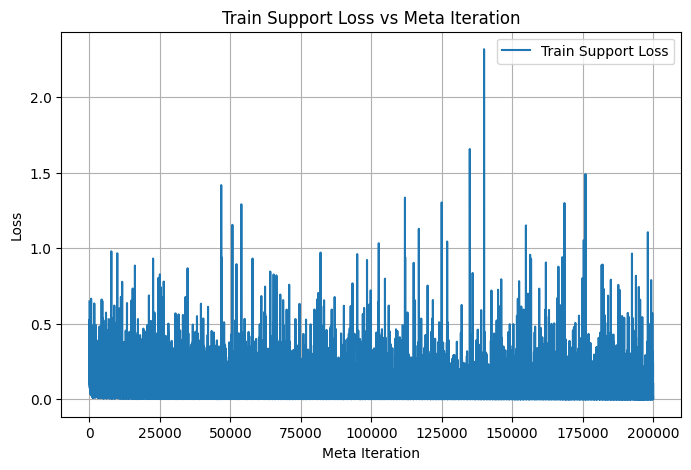

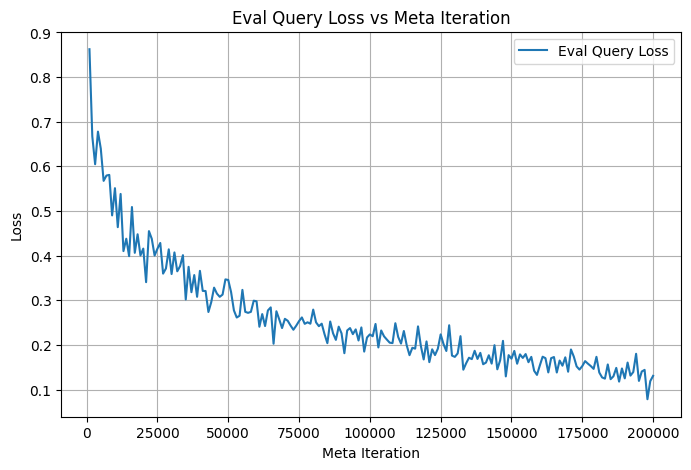

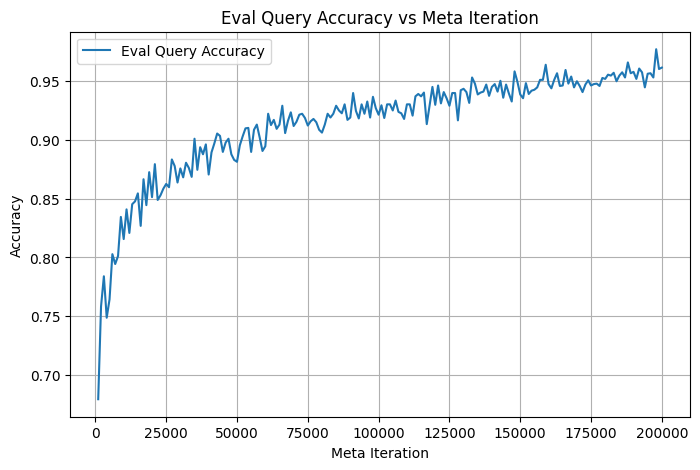

In [23]:
import matplotlib.pyplot as plt

# Train support loss
train_meta_iters = [x[0] for x in history["train_support_losses"]]
train_losses = [x[1] for x in history["train_support_losses"]]

plt.figure(figsize=(8, 5))
plt.plot(train_meta_iters, train_losses, label="Train Support Loss")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.title("Train Support Loss vs Meta Iteration")
plt.legend()
plt.grid(True)
plt.show()

if len(history["eval_query_losses"]) > 0:
    eval_meta_iters_loss = [x[0] for x in history["eval_query_losses"]]
    eval_losses = [x[1] for x in history["eval_query_losses"]]

    plt.figure(figsize=(8, 5))
    plt.plot(eval_meta_iters_loss, eval_losses, label="Eval Query Loss")
    plt.xlabel("Meta Iteration")
    plt.ylabel("Loss")
    plt.title("Eval Query Loss vs Meta Iteration")
    plt.legend()
    plt.grid(True)
    plt.show()

    eval_meta_iters_acc = [x[0] for x in history["eval_query_accuracies"]]
    eval_accs = [x[1] for x in history["eval_query_accuracies"]]

    plt.figure(figsize=(8, 5))
    plt.plot(eval_meta_iters_acc, eval_accs, label="Eval Query Accuracy")
    plt.xlabel("Meta Iteration")
    plt.ylabel("Accuracy")
    plt.title("Eval Query Accuracy vs Meta Iteration")
    plt.legend()
    plt.grid(True)
    plt.show()


In [22]:
avg_test_loss, avg_test_acc = evaluate_many_tasks(
    meta_model=meta_model,
    test_sampler=test_sampler,
    num_tasks=1000,
    n_way=5,
    k_shot=1,
    q_query=5,
    inner_lr=0.00044,
    inner_steps=86,
    inner_batch_size=10,
    transductive=False,
    device=device
)

print("Final average query loss:", avg_test_loss)
print("Final average query accuracy:", avg_test_acc)


Final average query loss: 0.2325279307225719
Final average query accuracy: 0.9355999820828438
